# Wallmart 데이터 분석

## 프로젝트 개요
[Kaggle의 Wallmart 데이터 셋](https://www.kaggle.com/datasets/devarajv88/walmart-sales-dataset) 분석 프로젝트입니다. 데이터 전처리, 탐색적 데이터 분석(EDA)을 통한 데이터의 분포를 확인하고, VIP 고객 도출 및 지역별 구매 고객 특징을 파악하여 마케팅 전략을 도출합니다.
이 프로젝트의 목표는 주어진 데이터의 분포를 분석하여 주요 특징을 도출하고, 이를 바탕으로 마케팅 전략을 제시하는 것입니다.

## 데이터 설명
- 데이터 출처: [Kaggle의 Wallmart 데이터 셋](https://www.kaggle.com/datasets/devarajv88/walmart-sales-dataset) 
- 데이터 상세: 약 55만개의 사용자 거래 내역과 10개의 특징(550068, 10)
  - `User_ID`: User ID
  - `Product_ID`: Product ID
  - `Gender`: Sex of User
  - `Age`: Age in bins
  - `Occupation`: Occupation(Masked)
  - `City_Category`: Category of the City (A,B,C)
  - `StayInCurrentCityYears`: Number of years stay in current city
  - `Marital_Status`: Marital Status
  - `ProductCategory`: Product Category (Masked)
  - `Purchase`: Purchase Amount


# 데이터 불러오기

In [48]:
import matplotlib.pyplot as plt

# 한글깨짐 방지
plt.rc('font', family='D2Coding')
# 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


In [4]:
import pandas as pd

df = pd.read_csv('./walmart.csv')
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


총 550,068 건의 데이터 확인 <br>
결측치는 확인되지 않았습니다.

## 데이터 구조 
[고객 + 품목]이 키값을 가지는 요약 테이블임 <br>
조사 기간은 알수 없으며, 구매금액(Purchase)은 해당 고객이 해당 품목에 대한 기간 중 총 구매금액으로 보임 (구매 회수는 알수 없음)

# EDA

In [6]:
# 몇명의 고객 정보인가?
# User-id 갯수
df['User_ID'].unique()   # Array Type
len(df['User_ID'].unique())

5891

총 5,891명의 사용자 거래 내역이 담겨 있습니다.

In [12]:
# 사용자 의존 정보만 추출
user_df = df.drop_duplicates(subset=['User_ID'], keep='first')
user_df = user_df.drop(columns=['Product_ID', 'Product_Category', 'Purchase'])
user_df

,User_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status
0,1000001,F,0-17,10,A,2,0
4,1000002,M,55+,16,C,4+,0
5,1000003,M,26-35,15,A,3,0
6,1000004,M,46-50,7,B,2,1
9,1000005,M,26-35,20,A,1,1
...,...,...,...,...,...,...,...
185450,1004588,F,26-35,4,C,0,0
187076,1004871,M,18-25,12,C,2,0
221494,1004113,M,36-45,17,C,3,0
229480,1005391,M,26-35,7,A,0,0


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '0-17'),
  Text(1, 0, '18-25'),
  Text(2, 0, '26-35'),
  Text(3, 0, '36-45'),
  Text(4, 0, '46-50'),
  Text(5, 0, '51-55'),
  Text(6, 0, '55+')])

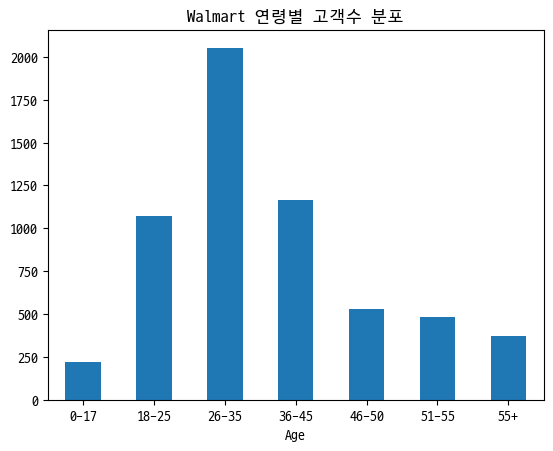

In [81]:
# 고객 연령대 별 분포
user_df.groupby('Age').size().plot(kind='bar')
plt.title("Walmart 연령별 고객수 분포")
plt.xticks(rotation=0)

In [7]:
# 한사람당 몇가지 물건을 사는 가?
# user_product_df = df.value_counts(df['User_ID'])
# user_product_df.describe()

user_purchase_df = df.groupby('User_ID')['Purchase'].aggregate(['count', 'sum'])
user_purchase_df

,count,sum
User_ID,,
1000001,35,334093
1000002,77,810472
1000003,29,341635
1000004,14,206468
1000005,106,821001
...,...,...
1006036,514,4116058
1006037,122,1119538
1006038,12,90034


In [55]:
user_purchase_df.columns = ['Product_Kinds', 'Purchase_Amount']
user_purchase_df.describe()

,Product_Kinds,Purchase_Amount
count,5891.000000,5.891000e+03
mean,93.374300,8.650166e+05
std,107.190049,9.436445e+05
min,6.000000,4.668100e+04
25%,26.000000,2.376780e+05
50%,54.000000,5.212130e+05
75%,117.000000,1.119250e+06
max,1026.000000,1.053691e+07


1인당 평균 93가지 물건을 사지만, 과도하게 많이 사는 사람들 때문에 실제 중간값은 54건이다. <br>
- Boxplot 을 통해 평균 및 이상치를 확인
- 직업별, 성별, 나이대별로 구매품목 수

In [56]:
# user_df = user_df.merge(user_purchase_df, on='User_ID')
user_stat_df = user_df.merge(user_purchase_df, on='User_ID').set_index(keys='User_ID').sort_index()
user_stat_df 

,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Kinds,Purchase_Amount
User_ID,,,,,,,,
1000001,F,0-17,10,A,2,0,35,334093
1000002,M,55+,16,C,4+,0,77,810472
1000003,M,26-35,15,A,3,0,29,341635
1000004,M,46-50,7,B,2,1,14,206468
1000005,M,26-35,20,A,1,1,106,821001
...,...,...,...,...,...,...,...,...
1006036,F,26-35,15,B,4+,1,514,4116058
1006037,F,46-50,1,C,4+,0,122,1119538
1006038,F,55+,1,C,2,0,12,90034


고객(사용자)별로 구매 품목 및 구매액을 포함하여 통계 테이블 구성

Text(0.5, 1.0, '고객별 구매제품 종류 분포')

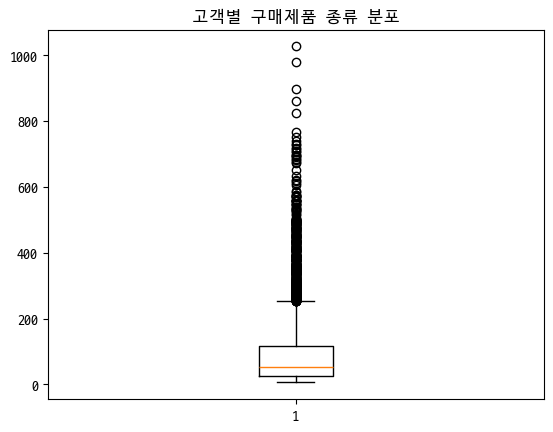

In [60]:
plt.boxplot(user_stat_df['Product_Kinds'])
plt.title('고객별 구매제품 종류 분포')

Text(0.5, 1.0, '고객별 구매액 분포')

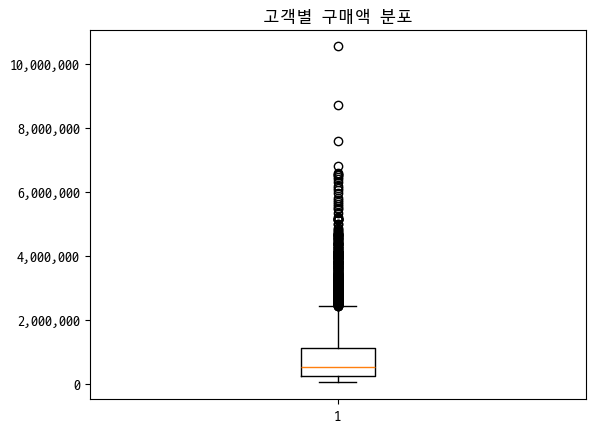

In [49]:
import matplotlib.ticker as ticker

plt.boxplot(user_stat_df['Purchase_Amount'])

# Y축 설정
ax = plt.gca() # 현재 축 가져오기

# 1. 지수 표기법 제거 (정수형 표시)
ax.get_yaxis().get_major_formatter().set_scientific(False)

# 2. 3자리마다 콤마 추가
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('고객별 구매액 분포')

In [67]:
user_stat_age_df = user_stat_df.groupby('Age').aggregate({'Product_Kinds':'mean', 'Purchase_Amount' : ['sum', 'mean']})
user_stat_age_df[('Product_Kinds', 'mean')] = round(user_stat_age_df[('Product_Kinds', 'mean')], 1)
user_stat_age_df[('Purchase_Amount', 'mean')] = round(user_stat_age_df[('Purchase_Amount', 'mean')], 1)
user_stat_age_df[('Purchase_Amount', 'sum')] = round(user_stat_age_df[('Purchase_Amount', 'sum')], 1)
user_stat_age_df

Product_Kinds Purchase_Amount          
               mean             sum      mean
Age                                          
0-17           69.3       134913183  618867.8
18-25          93.2       913848675  854863.1
26-35         107.0      2031770578  989659.3
36-45          94.3      1026569884  879665.7
46-50          86.1       420843403  792548.8
51-55          80.0       367099644  763200.9
55+            57.8       200767375  539697.2

Text(0.5, 1.0, '고객 연령대별 구매 품목 종류(평균)')

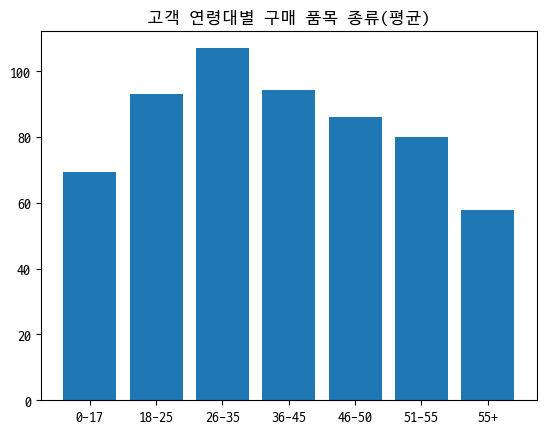

In [ ]:
plt.bar(user_stat_age_df.index, user_stat_age_df[('Product_Kinds', 'mean')])
plt.title("고객 연령대별 구매 품목 종류(평균)")

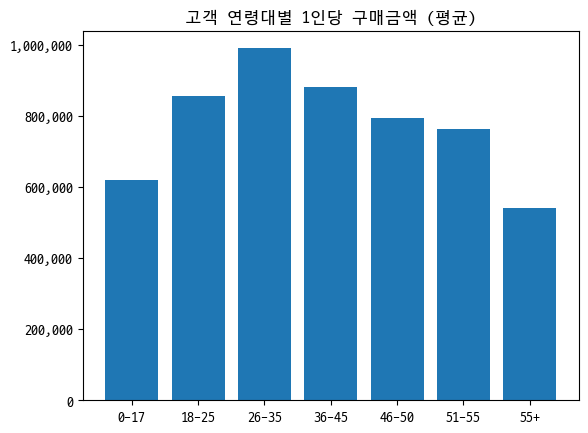

In [73]:
plt.bar(user_stat_age_df.index, user_stat_age_df[('Purchase_Amount', 'mean')])
plt.title("고객 연령대별 1인당 구매금액 (평균)")
# Y축 설정
ax = plt.gca() # 현재 축 가져오기

# 1. 지수 표기법 제거 (정수형 표시)
ax.get_yaxis().get_major_formatter().set_scientific(False)

# 2. 3자리마다 콤마 추가
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

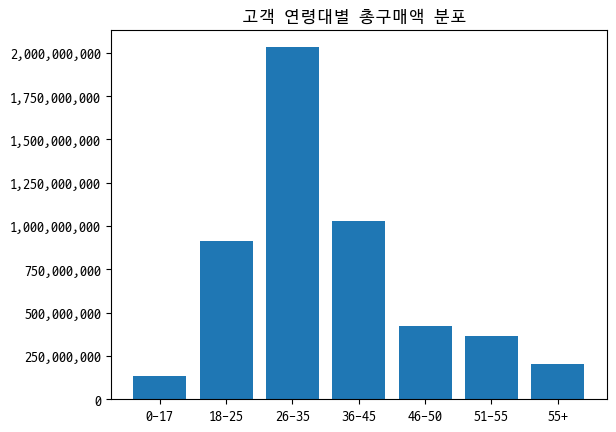

In [77]:
plt.bar(user_stat_age_df.index, user_stat_age_df[('Purchase_Amount', 'sum')])
plt.title("고객 연령대별 총구매액 분포 ")
# Y축 설정
ax = plt.gca() # 현재 축 가져오기

# 1. 지수 표기법 제거 (정수형 표시)
ax.get_yaxis().get_major_formatter().set_scientific(False)

# 2. 3자리마다 콤마 추가
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))


## 제품의 수 및 카테고리별 제품의 수

In [74]:
product_cnt = len(df['Product_ID'].unique())
print(product_cnt)

product_cat_df = df.groupby('Product_Category')['Product_ID'].unique().to_frame()
product_cat_df.columns = ['Product_List']
product_cat_df['Product_Kinds'] = [ len(x) for x in df_cat['Product_List'] ]
product_cat_df['Total_Purchase'] = df.groupby('Product_Category')['Purchase'].sum()
product_cat_df['Purchase_per_Product'] = round(df_cat_df['Total_Purchase'] / df_cat_df['Product_Kinds'], 0)
product_cat_df


3631


,Product_List,Product_Kinds,Total_Purchase,Purchase_per_Product
Product_Category,,,,
1,"[P00248942, P00193542, P00184942, P00346142, P...",493,1910013754,3874267.0
2,"[P0096642, P00085942, P00182642, P0094542, P00...",152,268516186,1766554.0
3,"[P00069042, P00058342, P00190742, P00190042, P...",90,204084713,2267608.0
4,"[P00190242, P00151842, P0094142, P00219242, P0...",88,27380488,311142.0
5,"[P00251242, P00231342, P00058442, P00220442, P...",967,941835229,973976.0
6,"[P00135742, P00148642, P00004742, P00101342, P...",119,324150302,2723952.0
7,"[P00110142, P00131942, P00020142, P00024042, P...",102,60896731,597027.0
8,"[P00285442, P00274942, P00014542, P00031342, P...",1047,854318799,815968.0
9,"[P00184242, P00075042]",2,6370324,3185162.0


제품 종류는 3631개 <br>
카테고리별 2개에서 많게는 1047개 임

Text(0.5, 1.0, '제품 카테고리별 제품수')

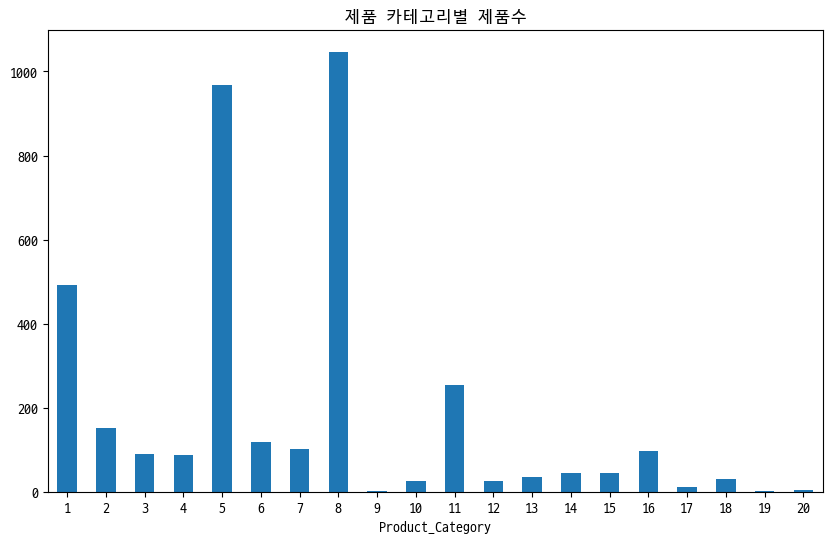

In [75]:
product_cat_df['Product_Kinds'].plot(kind='bar', figsize=(10, 6))
plt.xticks(rotation=0) 
plt.title('제품 카테고리별 제품수')

Text(0.5, 1.0, '제품 카테고리별 총구매액')

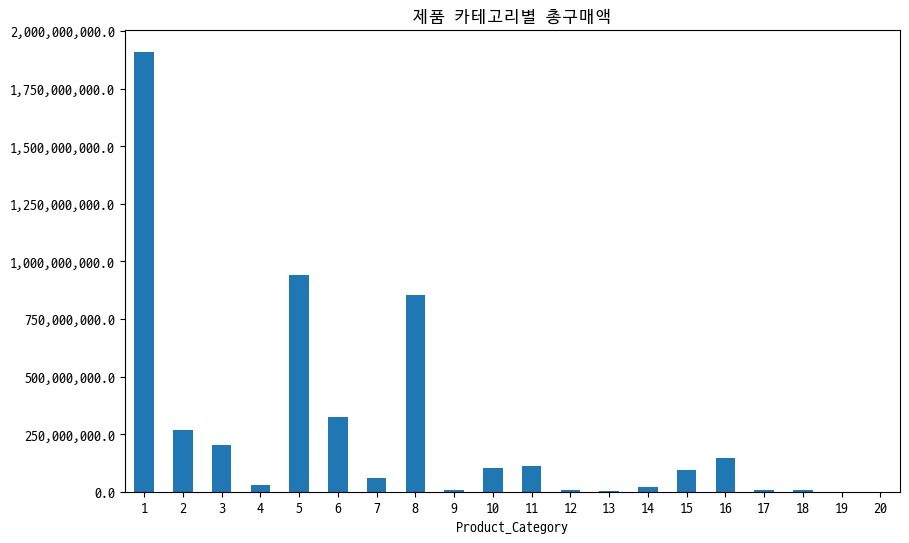

In [76]:
product_cat_df['Total_Purchase'].plot(kind='bar', figsize=(10, 6))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,}'))
plt.xticks(rotation=0) 
plt.title('제품 카테고리별 총구매액')

# 고객의 분포
- 고객 ID 단위로 고객수 파악 : 나이별, 연령별, 결혼유무, 지역별, 기간 등

In [41]:
# 나이별 분포
# user_age = user_stat_df['Age'].value_counts().sort_index(key=lambda x: x.str[:2])
# user_age.name = 'Number'
# user_age

user_age = user_stat_df.groupby(['Age'])[['Product_Count', 'Purchase_Amount']].aggregate({'Product_Count': 'mean', 'Purchase_Amount': ['mean','sum']})
user_age


Product_Count Purchase_Amount            
               mean            mean         sum
Age                                            
0-17      69.275229   618867.811927   134913183
18-25     93.227315   854863.119738   913848675
26-35    106.959084   989659.317097  2031770578
36-45     94.269923   879665.710368  1026569884
46-50     86.065913   792548.781544   420843403
51-55     80.043659   763200.923077   367099644
55+       57.806452   539697.244624   200767375

Text(0.5, 1.0, '고객 연령대 별 총구매액')

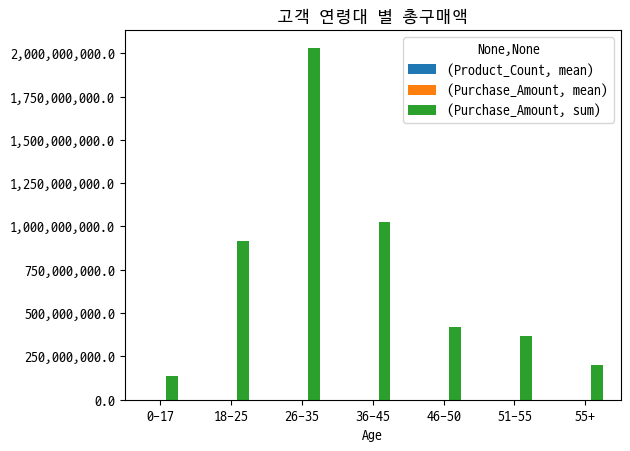

In [53]:
user_age.plot(kind='bar')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,}'))
plt.xticks(rotation=0) 
plt.title('고객 연령대 별 총구매액')


26~35세 연령대가 22만명 이상으로 경제활동이 활발한 소비 주도층이 주요 타깃 고객군일 가능성이 높습니다.<br>
18~25세와 36~45세 연령대가 안정적인 고객군으로 판단됩니다.<br>
10대의 경우 보호자 동반 방문으로 직접 방문하는 고객층의 패턴을 확인할 필요가 있습니다.<br>
50대 이상의 경우 구매력에 비해 방문횟수가 적어, 마케팅 강화의 여지를 확인할 필요가 있습니다.<br>

26-35세가 가장 구매력이 높게 나타남. 그 뒤로 36-45, 18-25 순임 <br>
구매빈도 및 구매금액이 비슷한 분포를 가짐

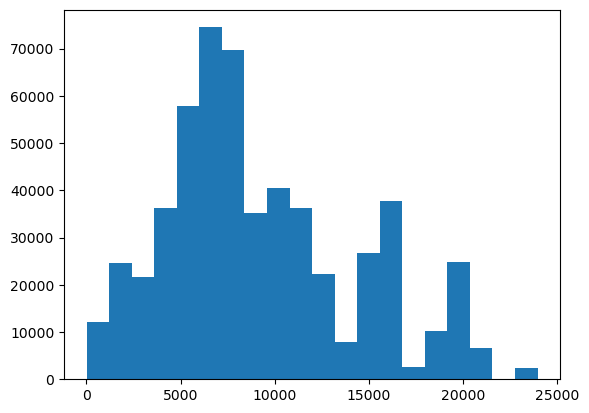

In [169]:
#구매한 제품의 가격대를 분석
plt.hist(df['Purchase'], bins=20)

plt.show()

In [170]:
#구매한 제품의 가격대를 분석


In [172]:
#상위 1% 가격의 구매제품 목록 - 이상치 확인
# df.sort_values(by='Purchase', ascending=False).head(10)
df_cat = df.groupby('Product_Category')['Purchase'].agg(['count', 'mean', 'sum'])
# df_cat = df.sort_values(by='mean', ascending=False)
df_cat.columns = ['Purchase_Count', 'Purchase_Mean', 'Purchase_Sum']
df_cat

,Purchase_Count,Purchase_Mean,Purchase_Sum
Product_Category,,,
1,140378,13606.218596,1910013754
2,23864,11251.935384,268516186
3,20213,10096.705734,204084713
4,11753,2329.659491,27380488
5,150933,6240.088178,941835229
6,20466,15838.478550,324150302
7,3721,16365.689600,60896731
8,113925,7498.958078,854318799
9,410,15537.375610,6370324


In [173]:
df_cat.sort_values(by='Purchase_Count', ascending=False)

,Purchase_Count,Purchase_Mean,Purchase_Sum
Product_Category,,,
5,150933,6240.088178,941835229
1,140378,13606.218596,1910013754
8,113925,7498.958078,854318799
11,24287,4685.268456,113791115
2,23864,11251.935384,268516186
6,20466,15838.478550,324150302
3,20213,10096.705734,204084713
4,11753,2329.659491,27380488
16,9828,14766.037037,145120612


상위 구매빈도 품목 카테고리 : 5, 1, 8, 11, 12

In [174]:
df_cat.sort_values(by='Purchase_Mean', ascending=False)

,Purchase_Count,Purchase_Mean,Purchase_Sum
Product_Category,,,
10,5125,19675.570927,100837301
7,3721,16365.689600,60896731
6,20466,15838.478550,324150302
9,410,15537.375610,6370324
15,6290,14780.451828,92969042
16,9828,14766.037037,145120612
1,140378,13606.218596,1910013754
14,1523,13141.625739,20014696
2,23864,11251.935384,268516186


상위 단가 품목 카테고리 : 10, 7, 6, 9, 15, 16, 1, ...

In [175]:
df_cat.sort_values(by='Purchase_Sum', ascending=False)

,Purchase_Count,Purchase_Mean,Purchase_Sum
Product_Category,,,
1,140378,13606.218596,1910013754
5,150933,6240.088178,941835229
8,113925,7498.958078,854318799
6,20466,15838.478550,324150302
2,23864,11251.935384,268516186
3,20213,10096.705734,204084713
16,9828,14766.037037,145120612
11,24287,4685.268456,113791115
10,5125,19675.570927,100837301


상위 매출 품목 카테고리 : 1, 5, 8, (6, 2, 3)

<Axes: xlabel='Product_Category'>

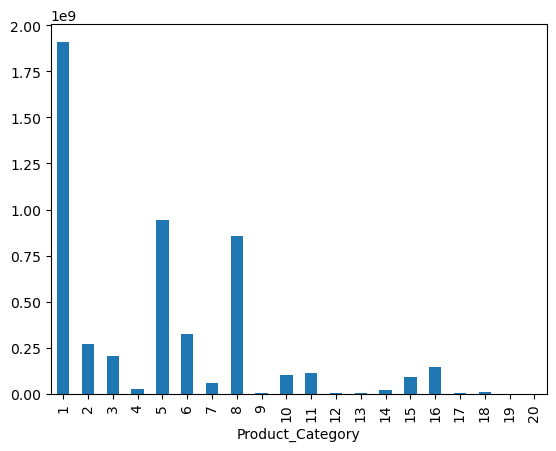

In [176]:
df_cat['Purchase_Sum']
df_cat['Purchase_Sum'].plot(kind='bar')

<Axes: xlabel='Product_Category'>

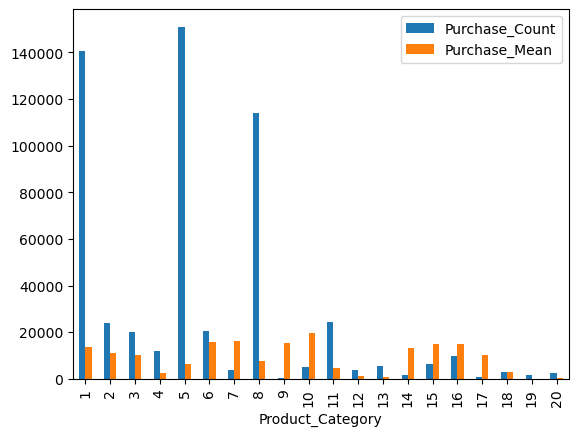

In [177]:
df_cat[['Purchase_Count', 'Purchase_Mean']]
df_cat[['Purchase_Count', 'Purchase_Mean']].plot(kind='bar')

구매건수 상위 카테고리 : 5, 1, 8, 11

<Axes: xlabel='Product_Category'>

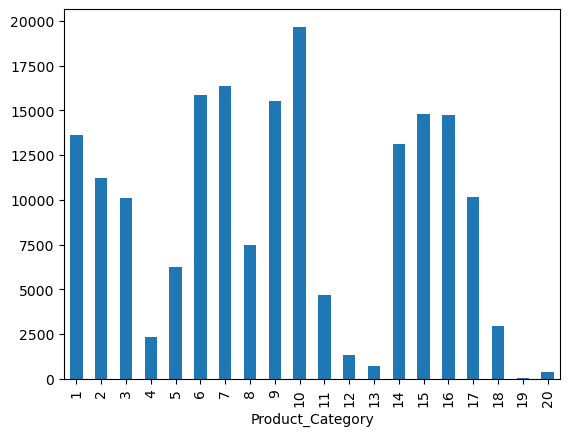

In [178]:
df_cat['Purchase_Mean'].plot(kind='bar')

구매 단가 상위 카테고리 : 10, 7, 6, 9, 15, 16

In [179]:
# 고가 전략 제품으로 카테고리 분석
product_cat = df[['Product_Category', 'Purchase']]
product_cat_purchase = df.groupby('Product_Category')['Purchase'].agg(['count', 'sum'])
product_cat_purchase

,count,sum
Product_Category,,
1,140378,1910013754
2,23864,268516186
3,20213,204084713
4,11753,27380488
5,150933,941835229
6,20466,324150302
7,3721,60896731
8,113925,854318799
9,410,6370324


10, 15, 16, 7번 카테고리 순으로 구매가 집중되고 있습니다.<BR>
해당 제품을 확인하여, 고부가가치 상품군이 존재할 가능성을 확인할 필요가 있습니다.<BR>

구매 건수 상위 제품에 대한 분석 (Category = 1, 5, 8)

In [180]:
# 구매 건수 상위 제품에 대한 분석 (Category = 1, 5, 8)

df_high_freq = df[df['Product_Category'].isin([1, 5, 8])]
df_high_freq

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
...,...,...,...,...,...,...,...,...,...,...
545910,1006040,P00184342,M,26-35,6,B,2,0,8,9855
545911,1006040,P00193142,M,26-35,6,B,2,0,5,1962
545912,1006040,P00029842,M,26-35,6,B,2,0,8,7852
545913,1006040,P00106042,M,26-35,6,B,2,0,5,7159


In [181]:
# 카테고리별 연령분포
df_high_freq.groupby(['Product_Category','Age', 'Gender']).size()

Product_Category  Age    Gender
1                 0-17   F           765
                         M          2820
                  18-25  F          4640
                         M         22322
                  26-35  F          9384
                         M         48865
                  36-45  F          5273
                         M         22375
                  46-50  F          2492
                         M          7982
                  51-55  F          1589
                         M          7460
                  55+    F           688
                         M          3723
5                 0-17   F          1511
                         M          2819
                  18-25  F          7928
                         M         20594
                  26-35  F         16586
                         M         44887
                  36-45  F          7817
                         M         21560
                  46-50  F          3756
                         

In [182]:
# 최다 판매 제품에 대한 분석 

df_high_freq = df[df['Product_Category']==1]
df_high_freq

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686
...,...,...,...,...,...,...,...,...,...,...
545887,1006036,P00127742,F,26-35,15,B,4+,1,1,11398
545889,1006036,P00129342,F,26-35,15,B,4+,1,1,7830
545890,1006036,P00244142,F,26-35,15,B,4+,1,1,7846
545908,1006040,P00127642,M,26-35,6,B,2,0,1,15694


In [183]:
df_high_freq.groupby(['Age', 'Gender']).size()
df_high_freq.groupby(['Age']).size()

Age
0-17      3585
18-25    26962
26-35    58249
36-45    27648
46-50    10474
51-55     9049
55+       4411
dtype: int64

In [184]:
df_high_freq.groupby(['Age']).size() / df_high_freq.shape[0]

Age
0-17     0.025538
18-25    0.192067
26-35    0.414944
36-45    0.196954
46-50    0.074613
51-55    0.064462
55+      0.031422
dtype: float64

In [185]:
df.groupby(['Age']).size() / df.shape[0]

Age
0-17     0.027455
18-25    0.181178
26-35    0.399200
36-45    0.199999
46-50    0.083082
51-55    0.069993
55+      0.039093
dtype: float64

In [186]:
stat_df_cat1_Age = (df.groupby(['Age']).size() / df.shape[0]).to_frame()
stat_df_cat1_Age.columns = ['All Categoires']
stat_df_cat1_Age

stat_df_cat1_Age['Category 1'] = df_high_freq.groupby(['Age']).size() / df_high_freq.shape[0]
stat_df_cat1_Age

,All Categoires,Category 1
Age,,
0-17,0.027455,0.025538
18-25,0.181178,0.192067
26-35,0.399200,0.414944
36-45,0.199999,0.196954
46-50,0.083082,0.074613
51-55,0.069993,0.064462
55+,0.039093,0.031422


<Axes: xlabel='Age'>

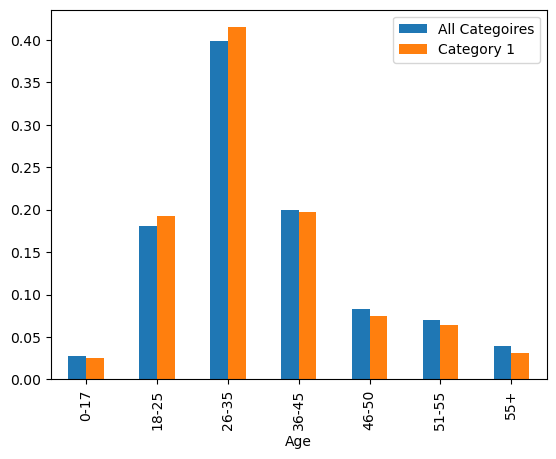

In [187]:
stat_df_cat1_Age.plot(kind='bar')

Category 1 제품은 제품 전체 대비 연령대별 구매 패턴의 큰 변동은 없어 보이나 젊은 층에서의 선호가 다소 높은 것으로 보임

In [188]:
df_high_freq.groupby(['Gender']).size()

Gender
F     24831
M    115547
dtype: int64

In [189]:
stat_df_cat1_gender = (df.groupby(['Gender']).size() / df.shape[0]).to_frame()
stat_df_cat1_gender.columns = ['All Categoires']
stat_df_cat1_gender

stat_df_cat1_gender['Category 1'] = df_high_freq.groupby(['Gender']).size() / df_high_freq.shape[0]
stat_df_cat1_gender

,All Categoires,Category 1
Gender,,
F,0.246895,0.176887
M,0.753105,0.823113


(array([0, 1]), [Text(0, 0, 'F'), Text(1, 0, 'M')])

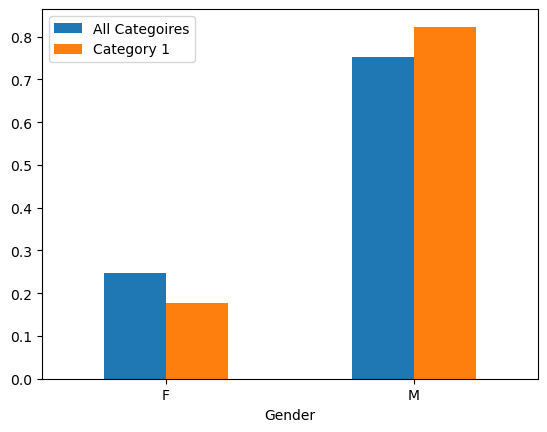

In [190]:
stat_df_cat1_gender.plot(kind='bar')
plt.xticks(rotation=0) 

위 제품은 대체로 남성 선호도가 높은 것으로 추정

In [191]:
# 연령/성별 선호도가 높은 제품

df_cat10 = df[df['Product_Category']==10]


stat_cat10_gender = (df.groupby(['Gender']).size() / df.shape[0]).to_frame()
stat_cat10_gender.columns = ['All Categoires']
stat_cat10_gender

stat_cat10_gender['Category 10'] = df_cat10.groupby(['Gender']).size() / df_cat10.shape[0]
stat_cat10_gender



,All Categoires,Category 10
Gender,,
F,0.246895,0.226732
M,0.753105,0.773268


(array([0, 1]), [Text(0, 0, 'F'), Text(1, 0, 'M')])

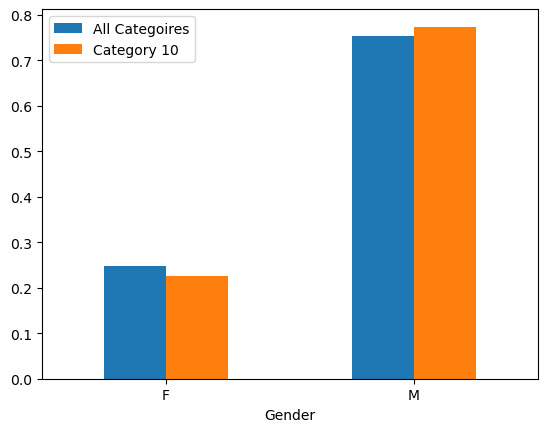

In [192]:
stat_cat10_gender.plot(kind='bar')
plt.xticks(rotation=0) 

In [193]:
stat_cat10_Age = (df.groupby(['Age']).size() / df.shape[0]).to_frame()
stat_cat10_Age.columns = ['All Categoires']
stat_cat10_Age

stat_cat10_Age['Category 10'] = df_cat10.groupby(['Age']).size() / df_cat10.shape[0]
stat_cat10_Age

,All Categoires,Category 10
Age,,
0-17,0.027455,0.021659
18-25,0.181178,0.117659
26-35,0.399200,0.348683
36-45,0.199999,0.240976
46-50,0.083082,0.101463
51-55,0.069993,0.101268
55+,0.039093,0.068293


Text(0, 0.5, 'Purchase Percentage')

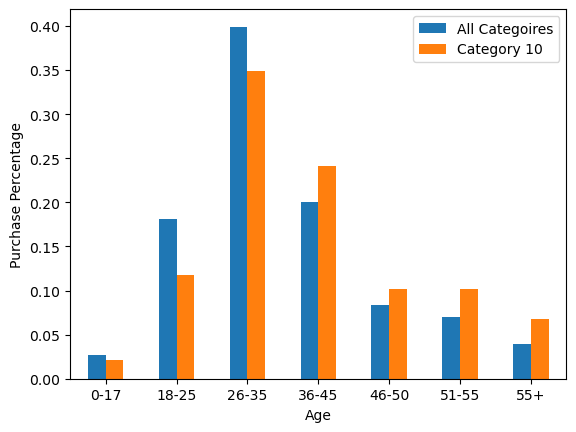

In [194]:
stat_cat10_Age.plot(kind='bar')
plt.xticks(rotation=0) 
plt.ylabel("Purchase Percentage") 

category 10 제품은 고가이며, 높은 연령층에서 구매빈도가 높은 것으로 판단됨 - 고가의 제품

In [195]:
import numpy as np

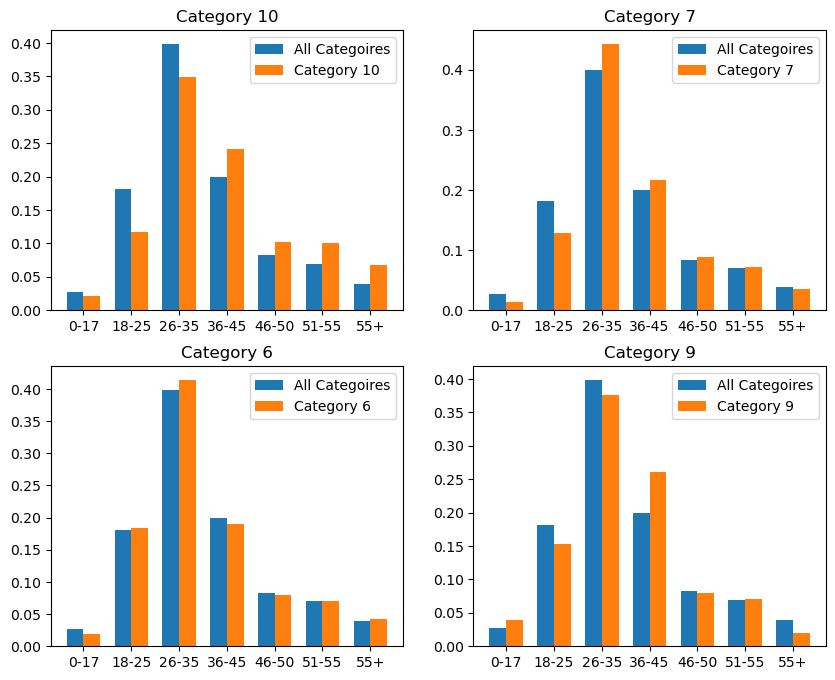

In [196]:

# 2x2 서브플롯 생성 (figsize로 크기 조절)
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# 고가품 10, 7, 6, 9
high_categories = [10, 7, 6, 9]

stat_cat_age = (df.groupby(['Age']).size() / df.shape[0]).to_frame()
stat_cat_age.columns = ['All Categoires']

x = np.arange(len(stat_cat_age.index))  # x축 눈금 위치 (0, 1, 2...)
width = 0.35  

for i in range(0, 4) :
    ix, iy = divmod(i,2)
    cat = high_categories[i]
    
    cat_column =  f"Category {cat}"
    df_catN = df[df['Product_Category']==cat]
    stat_cat_age[cat_column] = df_catN.groupby(['Age']).size() / df_catN.shape[0]
    
    # axs[ix, iy].plot(stat_cat_age.index, stat_cat_age[['All Categoires', cat_column]])
    # axs[ix, iy].set_title(f"Category {cat}")
    
    # 첫 번째 막대 (왼쪽으로 width/2 이동)
    axs[ix, iy].bar(x - width/2, stat_cat_age['All Categoires'], width, label='All Categoires')
    
    # 두 번째 막대 (오른쪽으로 width/2 이동)
    axs[ix, iy].bar(x + width/2, stat_cat_age[cat_column], width, label=cat_column)
    
    axs[ix, iy].set_xticks(x)
    axs[ix, iy].set_xticklabels(stat_cat_age.index)
    axs[ix, iy].set_title(cat_column)
    axs[ix, iy].legend()


plt.show()
# for category in high_categories

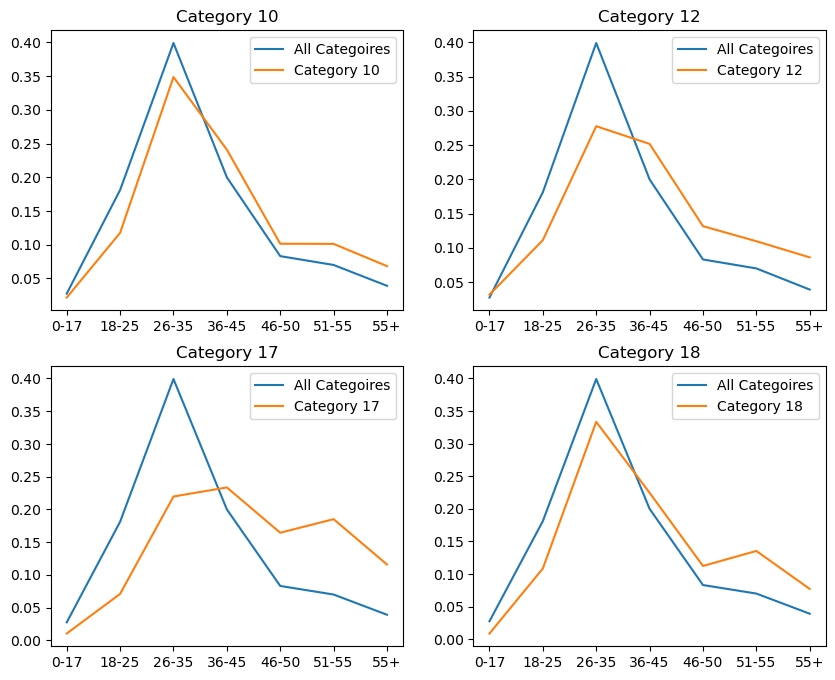

In [197]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# 고가품 10, 7, 6, 9
# high_categories = [10, 7, 6, 9]
# 특이 제품
high_categories = [10, 12, 17, 18]

stat_cat_age = (df.groupby(['Age']).size() / df.shape[0]).to_frame()
stat_cat_age.columns = ['All Categoires']

x = np.arange(len(stat_cat_age.index))  # x축 눈금 위치 (0, 1, 2...)
width = 0.35  

for i in range(0, 4) :
    ix, iy = divmod(i,2)
    cat = high_categories[i]
    
    cat_column =  f"Category {cat}"
    df_catN = df[df['Product_Category']==cat]
    stat_cat_age[cat_column] = df_catN.groupby(['Age']).size() / df_catN.shape[0]
   
    cols =  ['All Categoires', cat_column]
    axs[ix, iy].plot(stat_cat_age.index, stat_cat_age[cols], label=cols)
    axs[ix, iy].set_title(cat_column)
    axs[ix, iy].legend()


plt.show()

제품 카테고리별로 전체 연령분포와 유사한 분포를 가지고 있으나, 일부 카테고리는 높은 연령층에서 선호도를 보임 <br>
낮은 연령에서 선호를 보이는 제품은 뚜렷이 없음

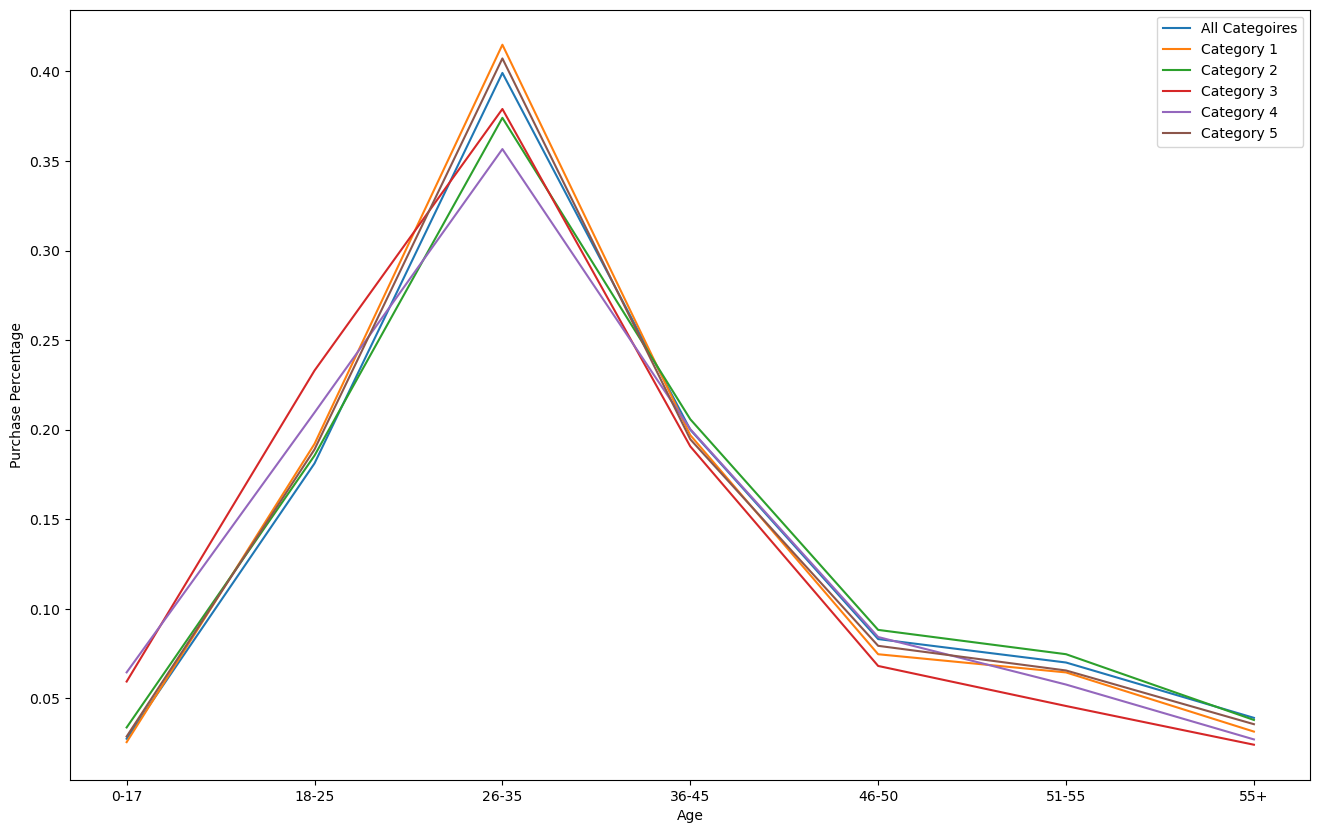

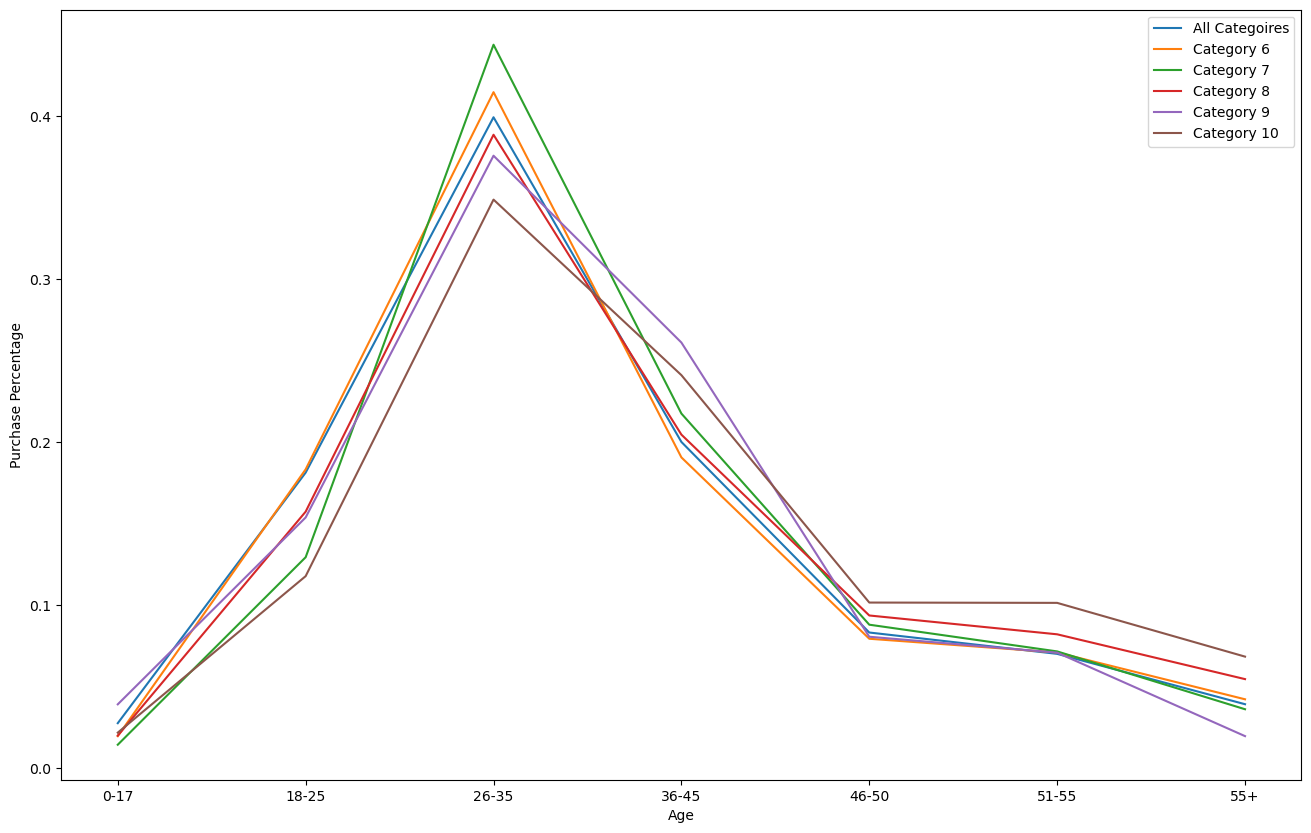

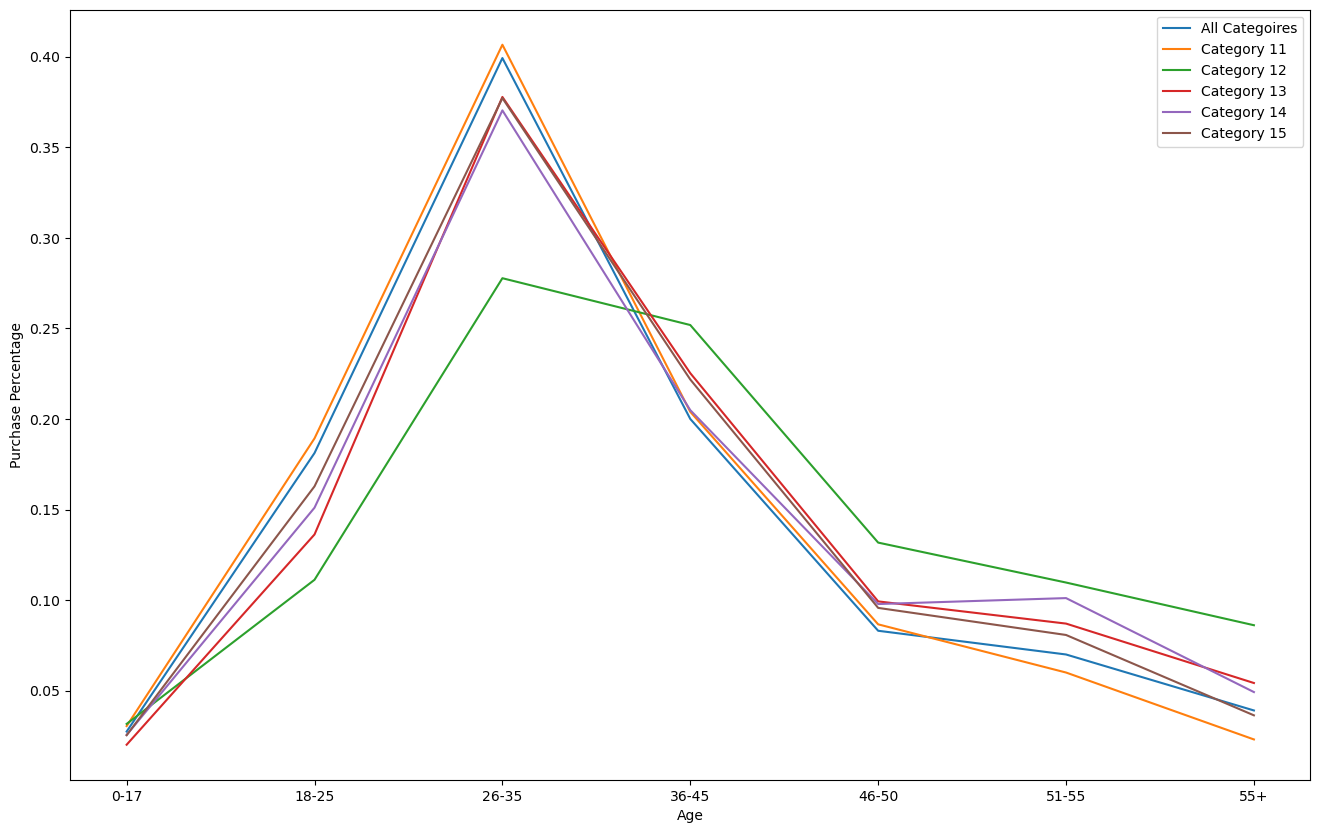

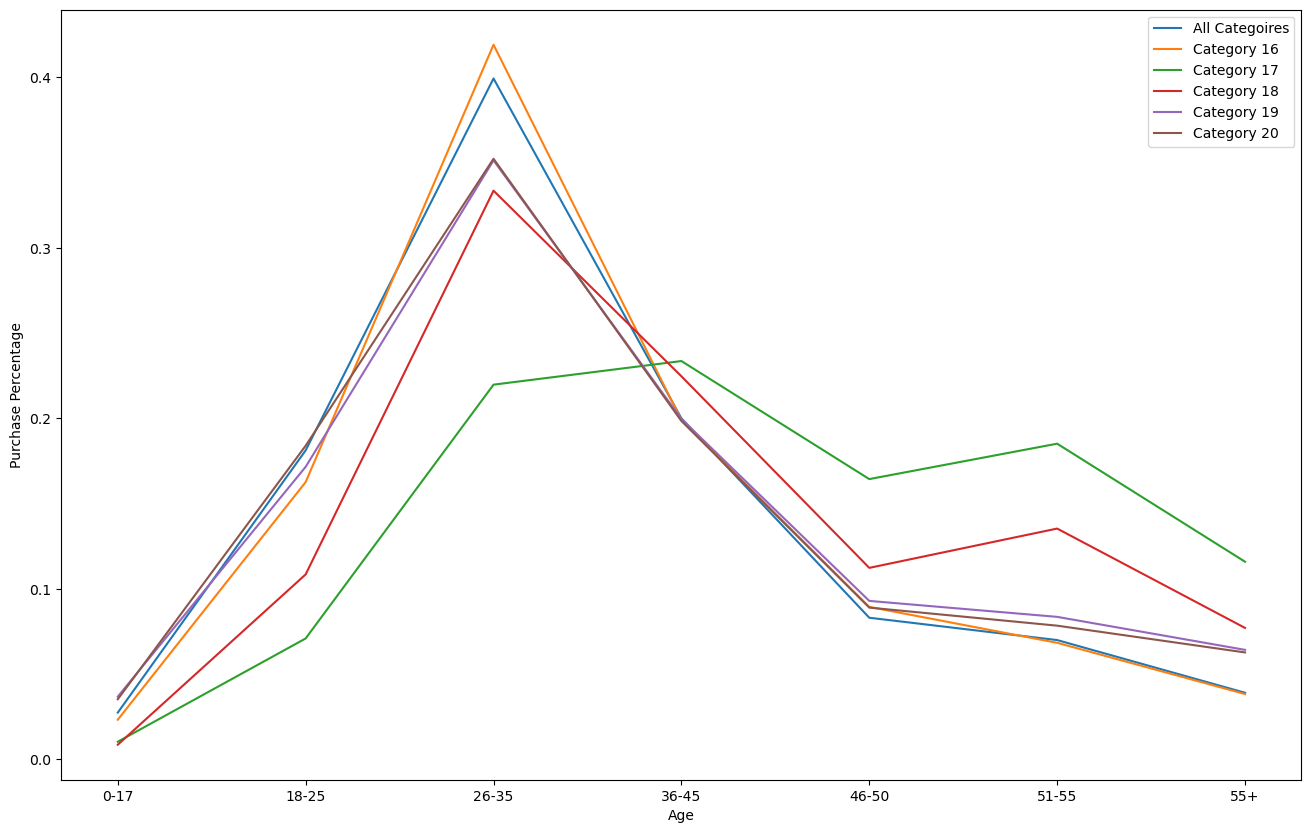

In [198]:
categories = df['Product_Category'].unique()
categories.sort()
categories

stat_cat_age = (df.groupby(['Age']).size() / df.shape[0]).to_frame()
stat_cat_age.columns = ['All Categoires']

for cat in categories :
    cat_column =  f"Category {cat}"
    df_catN = df[df['Product_Category']==cat]
    stat_cat_age[cat_column] = df_catN.groupby(['Age']).size() / df_catN.shape[0]
    
stat_cat_age

stat_cat_age.iloc[:, 0:6].plot(kind='line', figsize=(16, 10))
# stat_cat_age.plot(kind='line', figsize=(16, 10))
plt.xticks(rotation=0) 
plt.ylabel("Purchase Percentage") 


stat_cat_age.iloc[:, [0, 6,7,8,9,10]].plot(kind='line', figsize=(16, 10))
# stat_cat_age.plot(kind='line', figsize=(16, 10))
plt.xticks(rotation=0) 
plt.ylabel("Purchase Percentage") 


stat_cat_age.iloc[:, [0,11,12,13,14,15]].plot(kind='line', figsize=(16, 10))
# stat_cat_age.plot(kind='line', figsize=(16, 10))
plt.xticks(rotation=0) 
plt.ylabel("Purchase Percentage") 

stat_cat_age.iloc[:, [0,16,17,18,19,20]].plot(kind='line', figsize=(16, 10))
# stat_cat_age.plot(kind='line', figsize=(16, 10))
plt.xticks(rotation=0) 
plt.ylabel("Purchase Percentage")

plt.show()
    

In [199]:
stat_cat_age.iloc[:,0:11].describe()

,All Categoires,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857
std,0.131283,0.139262,0.122360,0.130584,0.118115,0.134965,0.136829,0.148505,0.124775,0.131231,0.112782
min,0.027455,0.025538,0.033733,0.024093,0.027057,0.028688,0.019496,0.014243,0.019820,0.019512,0.021659
25%,0.054543,0.047942,0.056277,0.052540,0.061091,0.050552,0.056484,0.053749,0.068238,0.054878,0.084780
50%,0.083082,0.074613,0.088208,0.068075,0.084234,0.079313,0.079253,0.087880,0.093535,0.080488,0.101463
75%,0.190588,0.194511,0.195692,0.211844,0.204926,0.191804,0.186846,0.173340,0.180851,0.207317,0.179317
max,0.399200,0.414944,0.374120,0.379063,0.356675,0.407287,0.414590,0.443698,0.388466,0.375610,0.348683


In [200]:
stat_cat_age.iloc[:,11:].describe()

,Category 11,Category 12,Category 13,Category 14,Category 15,Category 16,Category 17,Category 18,Category 19,Category 20
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857
std,0.136880,0.089309,0.122415,0.116855,0.124296,0.137481,0.081479,0.106079,0.108695,0.110769
min,0.023099,0.031670,0.020184,0.025607,0.025437,0.023301,0.010381,0.008640,0.036806,0.035294
25%,0.045251,0.097922,0.070643,0.073539,0.058585,0.053368,0.093426,0.092800,0.073924,0.070588
50%,0.086631,0.111224,0.099297,0.101116,0.095707,0.089438,0.164360,0.112320,0.092951,0.089020
75%,0.196607,0.191791,0.180753,0.177938,0.192289,0.180759,0.202422,0.180000,0.185590,0.191176
max,0.406555,0.277679,0.377726,0.370322,0.377107,0.419007,0.233564,0.333440,0.351216,0.352157


In [201]:
# df['Marital_Status'].unique()

df.groupby(['Marital_Status', 'Product_Category'])['Purchase'].agg(['count', 'sum'])
# df.groupby('Marital_Status')[['Product_Category', 'Purchase']].agg('count', 'sum', 'mean')

count         sum
Marital_Status Product_Category                   
0              1                 84375  1146594992
               2                 14138   158009058
               3                 12359   123922879
               4                  7177    16564669
               5                 89656   558005574
               6                 12139   192581656
               7                  2040    33484311
               8                 65411   489533223
               9                   247     3922592
               10                 2778    54630983
               11                14668    69308836
               12                 2034     2745347
               13                 3162     2292541
               14                  846    11069661
               15                 3623    53498269
               16                 5713    84241239
               17                  298     3019460
               18                 1641     4923284
               19                  946       35260
               20                 1480      543613
1              1                 56003   763418762
               2                  9726   110507128
               3                  7854    80161834
               4                  4576    10815819
               5                 61277   383829655
               6                  8327   131568646
               7                  1681    27412420
               8                 48514   364785576
               9                   163     2447732
               10                 2347    46206318
               11                 9619    44482279
               12                 1913     2586497
               13                 2387     1716060
               14                  677     8945035
               15                 2667    39470773
               16                 4115    60879373
               17                  280     2859239
               18                 1484     4366917
               19                  657       24118
               20                 1070      401114

In [202]:
mar_df = df.groupby(["Product_Category", 'Marital_Status'])['Purchase'].agg(['count', 'sum'])
mar_df

mar_df.loc[(1,0), 'sum']
# zz = f"{mar_df.index[0]}.{mar_df.index[1]}"
# mar_df.index = mar_df.index.map(lambda x: '_'.join(map(str, x)))
# mar_df.index

# mar_df.columns=['Total_Visits', 'Total_Purchase']

# mar_df

1146594992

In [203]:
#저가 제품의 카테고리 집중도
